In [9]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
TICKS   = "../data/INTC_trades(XNASITCH).parquet"
OUT     = "../data/daily_proxies.parquet"
FREQ    = "30s"   # from Part 1
EARNINGS = pd.to_datetime([
    "2023-01-27", "2023-04-28", "2023-07-28", "2023-10-27",
    "2024-01-26", "2024-04-26", "2024-08-02", "2024-11-01",
    "2025-01-31", "2025-04-25", "2025-07-25", "2025-10-24",
]).tz_localize("America/New_York")

In [2]:
# Define a daily_rv function that takes df and freq and returns a DataFrame with daily realized volatility

def clean_trades(raw, tz="America/New_York", start="09:30:00", end="16:00:00"):
    """Keep valid trades, index by exchange timestamp in local tz, restrict to RTH."""
    df = raw[(raw["price"] > 0) & (raw["size"] > 0)].copy()
    df = df.set_index("ts_event")
    df.index = df.index.tz_convert(tz)
    return df.between_time(start, end)

def daily_rv(df, freq):
    day = df.index.normalize()
    prices = (
        df["price"]
        .groupby(day)
        .resample(freq)
        .last()
        .ffill()
        .droplevel(0)
    )

    #Get opening price for each day
    opens = df["price"].groupby(day).first()

    #Add openings to resampled prices
    prices = pd.concat([opens, prices]).sort_index()
    
    logp = np.log(prices)

    rv_daily = (
        logp.groupby(logp.index.normalize())
        .apply(lambda x: (x.diff() ** 2).sum())
    )

    return rv_daily

In [3]:
# Take raw (cleaned) tick data and return a DataFrame with 1 row per day with the following columns: O, H, L, C, n_trades, rv

def daily_panel(df, FREQ):
    day = df.index.normalize()
    opens = df["price"].groupby(day).first()
    closes = df["price"].groupby(day).last()
    highs = df["price"].groupby(day).max()
    lows = df["price"].groupby(day).min()
    n_trades = df.groupby(day).size()
    rv = daily_rv(df, FREQ)

    panel = pd.DataFrame({"O": opens, "H": highs, "L": lows, "C": closes, "n_trades": n_trades, "rv": rv})

    return panel



In [18]:
# Given the raw data, clean it, loop through one month at a time compute the daily panel, and save it to a parquet file

months = pd.date_range(start="2023-01-01", end="2026-01-01", freq="MS", tz="UTC")
panels = []

for start, end in zip(months[:-1], months[1:]):
    raw = pd.read_parquet(TICKS, filters=[("ts_event", ">=", start), ("ts_event", "<", end)])
    df = clean_trades(raw)

    if df.empty:
        continue

    panels.append(daily_panel(df, FREQ))

panel = pd.concat(panels).sort_index()

In [19]:
print(len(panel), panel.index.duplicated().sum(), panel.isna().sum().sum())
print(panel.head())

752 0 0
                               O       H      L       C  n_trades        rv
ts_event                                                                   
2023-01-03 00:00:00-05:00  27.03  27.065  26.37  26.720     29360  0.000374
2023-01-04 00:00:00-05:00  27.40  27.915  27.16  27.685     37005  0.000522
2023-01-05 00:00:00-05:00  27.45  27.775  27.38  27.590     24317  0.000284
2023-01-06 00:00:00-05:00  27.91  28.830  27.39  28.710     28299  0.000338
2023-01-09 00:00:00-05:00  28.85  29.865  28.85  29.330     33919  0.000323


In [20]:
# Use the panel to compute a DataFrame with the following columns: date, rv_intraday, V_GK, V_CC
# Returns original rows minus the first row (which has no previous close)

def compute_proxies(panel):
    p = panel.copy()

    prev = p["C"].shift(1)          # previous close
    r_on = np.log(p["O"] / prev)            # overnight return
    r_cc = np.log(p["C"] / prev)            # close-to-close return
    gk = 0.5*np.log(p["H"]/p["L"])**2 - (2*np.log(2)-1)*np.log(p["C"]/p["O"])**2

    p["V_rv"]    = r_on**2 + p["rv"]
    p["V_GK"]    = r_on**2 + gk
    p["V_CC"]    = r_cc**2

    return p.iloc[1:]

p = compute_proxies(panel)
p["is_earnings"] = p.index.normalize().isin(EARNINGS)

print(len(p), p.isna().sum().sum(), (p["V_CC"] == 0).sum())
print(p.head())

751 0 4
                               O       H      L       C  n_trades        rv  \
ts_event                                                                      
2023-01-04 00:00:00-05:00  27.40  27.915  27.16  27.685     37005  0.000522   
2023-01-05 00:00:00-05:00  27.45  27.775  27.38  27.590     24317  0.000284   
2023-01-06 00:00:00-05:00  27.91  28.830  27.39  28.710     28299  0.000338   
2023-01-09 00:00:00-05:00  28.85  29.865  28.85  29.330     33919  0.000323   
2023-01-10 00:00:00-05:00  29.25  29.510  28.92  29.450     24215  0.000265   

                               V_rv      V_GK      V_CC  is_earnings  
ts_event                                                              
2023-01-04 00:00:00-05:00  0.001154  0.000966  0.001259        False  
2023-01-05 00:00:00-05:00  0.000356  0.000165  0.000012        False  
2023-01-06 00:00:00-05:00  0.000471  0.001137  0.001583        False  
2023-01-09 00:00:00-05:00  0.000347  0.000516  0.000456        False  
2023-01-10 0

In [24]:
p.to_parquet(OUT)

In [21]:
p["is_earnings"].sum()

np.int64(12)

In [22]:
print(p[["V_rv","V_GK","V_CC"]].nlargest(5, "V_rv"))

                               V_rv      V_GK      V_CC
ts_event                                               
2024-08-02 00:00:00-04:00  0.083454  0.082761  0.092391
2025-09-18 00:00:00-04:00  0.062473  0.061491  0.042252
2025-03-13 00:00:00-04:00  0.019060  0.018199  0.018761
2024-01-26 00:00:00-05:00  0.014827  0.014452  0.016447
2023-01-27 00:00:00-05:00  0.012061  0.011771  0.004350


In [25]:
# Run stats on the proxies

V = p[["V_rv", "V_GK", "V_CC"]]

# dispersion: robust, since std is dominated by 2024-08-02
q = V.quantile([0.25, 0.5, 0.75])
disp = pd.DataFrame({
    "mean":       V.mean(),
    "median":     q.loc[0.5],
    "IQR/median": (q.loc[0.75] - q.loc[0.25]) / q.loc[0.5],
    "sd(log)":    np.log(V.replace(0, np.nan)).std(),
})
print(disp, "\n")

# agreement: logs, so one crash doesn't set the answer
print(np.log(V.replace(0, np.nan)).corr(), "\n")

# bias (median) vs unbiasedness (mean), both vs V_rv
ratio = V.div(V["V_rv"], axis=0)
print("median ratio to V_rv:\n", ratio.median(), "\n")
print("mean ratio of totals:\n", V.mean() / V["V_rv"].mean(), "\n")

print("zero V_CC days:", (V["V_CC"] == 0).sum())

          mean    median  IQR/median   sd(log)
V_rv  0.001048  0.000471    1.018252  0.844974
V_GK  0.001056  0.000447    1.233427  0.990183
V_CC  0.001097  0.000273    2.962529  2.234659 

          V_rv      V_GK      V_CC
V_rv  1.000000  0.903922  0.452295
V_GK  0.903922  1.000000  0.492809
V_CC  0.452295  0.492809  1.000000 

median ratio to V_rv:
 V_rv    1.000000
V_GK    0.929708
V_CC    0.589299
dtype: float64 

mean ratio of totals:
 V_rv    1.000000
V_GK    1.007324
V_CC    1.047026
dtype: float64 

zero V_CC days: 4


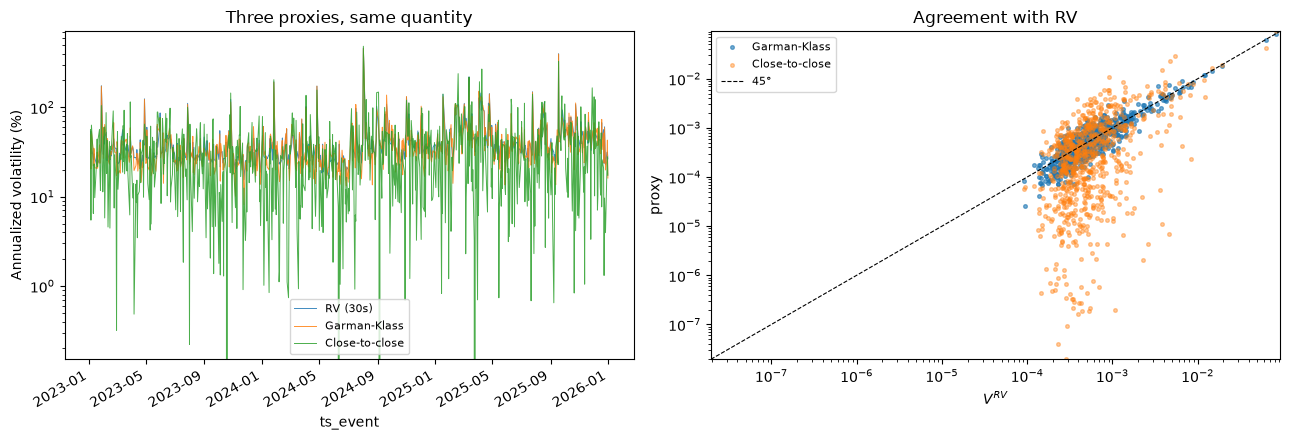

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# left: the three proxies in annualized vol units
np.sqrt(V * 252).mul(100).plot(ax=ax[0], lw=0.7, alpha=0.85)
ax[0].set_yscale("log")
ax[0].set_ylabel("Annualized volatility (%)")
ax[0].set_title("Three proxies, same quantity")
ax[0].legend(["RV (30s)", "Garman-Klass", "Close-to-close"], fontsize=8)

# right: each proxy against RV, log-log, 45-degree line
ax[1].scatter(V["V_rv"], V["V_GK"], s=7, alpha=0.6, label="Garman-Klass")
ax[1].scatter(V["V_rv"], V["V_CC"], s=7, alpha=0.4, label="Close-to-close")
lim = [V[V > 0].min().min(), V.max().max()]
ax[1].plot(lim, lim, "k--", lw=0.8, label="45°")
ax[1].set(xscale="log", yscale="log", xlim=lim, ylim=lim,
          xlabel="$V^{RV}$", ylabel="proxy")
ax[1].set_title("Agreement with RV")
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.show()